# Distributions, Models, and Comparing Distributions

## Outline

* [Distributions](#Distributions)
* [Law of Large Numbers](#Law-of-Large-Numbers)
* [A Statistic](#A-Statistic)

---

## Set Up the Notebook

In [1]:
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

---

## Distributions

---

## Distributions
What is the distribution of a variable?
<p>
The distribution of a variable consists of all values of the variable that occur in the data, along with their frequencies.
Distributions help you understand:
How often does a variable take on a certain value?

Both categorical and numerical variables have distributions.
#### Distributions of categorical variables
<p>The distribution of a categorical variable can be displayed as a table or bar chart, among other ways!

---


## Probability distributions 

Consider a random quantity with various possible values, each of which has some associated probability.

A probability distribution is a description of:
* All possible values of the quantity.
* The theoretical probability of each value.

---

Create a table with the face numbers of a six-sided die. Use that table with the `sample` method to simulate randomly rolling a die. Visualize the probability distribution.

### Example: Probability distribution of a die roll 
As we increase the number of rolls in the simulation, the area of each bar gets closer to 16.67%, which is the area of each bar in the probability histogram.

The histogram below helps us visualize the fact that every face appears with probability 1/6. We say that the histogram shows the distribution of probabilities over all the possible faces. 

Since all the bars represent the same percent chance, the distribution is called uniform on the integers 1 through 6.

In [2]:
die = Table().with_column('Face', np.arange(1, 7, 1))
die

Face
1
2
3
4
5
6


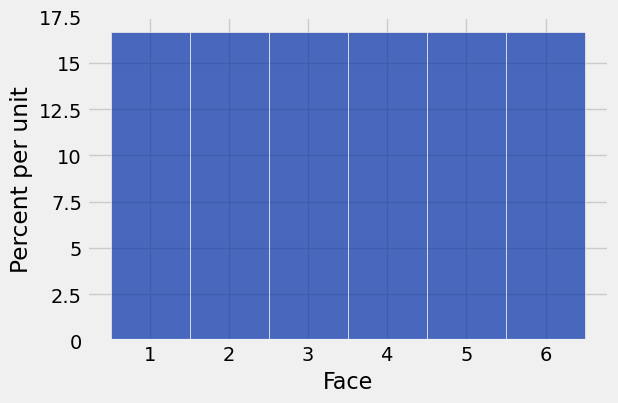

In [3]:
die_bins = np.arange(0.5, 6.6, 1)
die.hist(bins = die_bins)

In [4]:
die.sample(10)

Face
4
4
4
1
4
4
2
2
5
5


As we increase the number of rolls in the simulation, the area of each bar gets closer to 16.67%, which is the area of each bar in the probability histogram.

The histogram below helps us visualize the fact that every face appears with probability 1/6. We say that the histogram shows the distribution of probabilities over all the possible faces. 

Since all the bars represent the same percent chance, the distribution is called uniform on the integers 1 through 6.

## Empirical distributions

Empirical distributions are distributions of observed data. 
Unlike probability distributions, which are theoretical, empirical distributions are based on observations.
Commonly, these observations are of repetitions of an experiment.

An empirical distribution describes:
* All observed values.
* The proportion of experiments in which each value occurred.
Unlike probability distributions, empirical distributions represent what actually happened in practice.

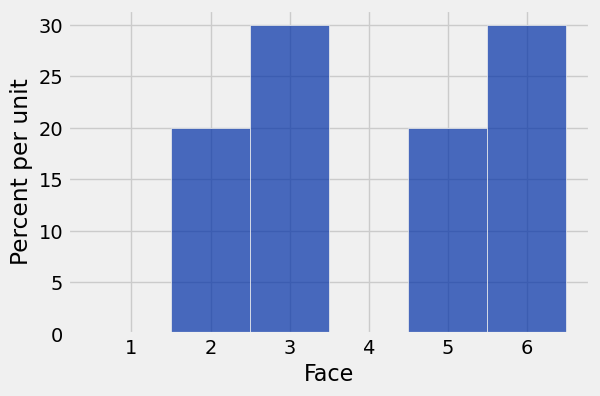

In [5]:
def empirical_hist_die(n):
    die.sample(n).hist(bins = die_bins)
empirical_hist_die(10)

---

Randomly sample using a few different sample sizes and visualize the resulting empirical distributions.

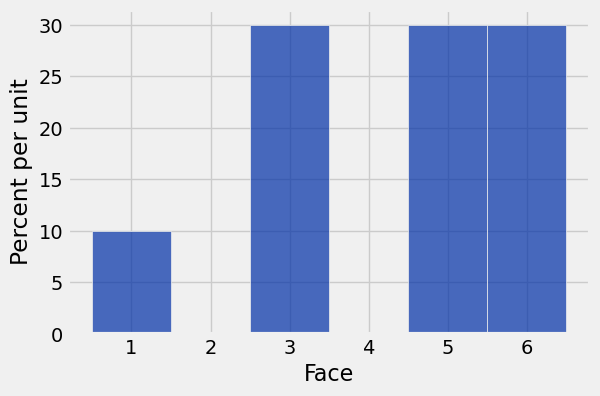

In [6]:
empirical_hist_die(10)

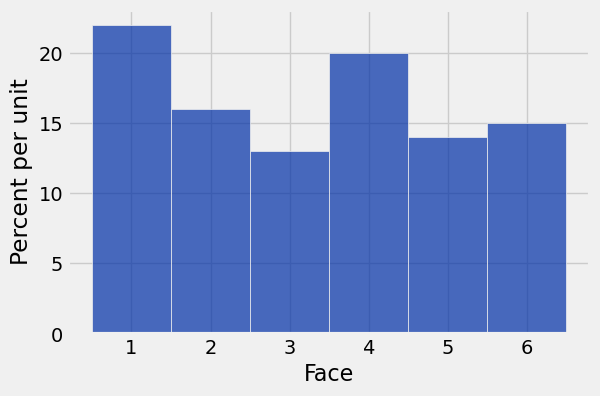

In [6]:
empirical_hist_die(100)

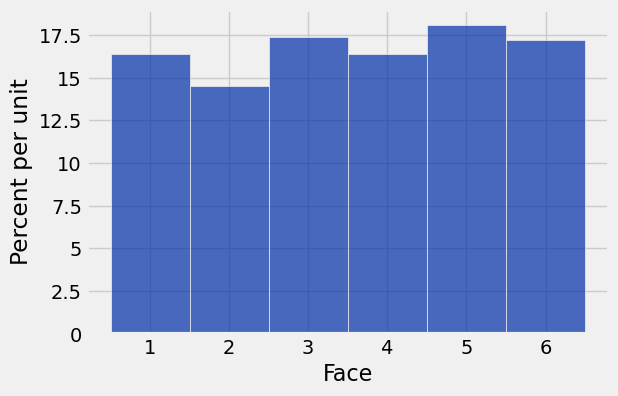

In [7]:
empirical_hist_die(1000)

---

## Law of Large Numbers

---

### Law of Averages / Law of Large Numbers

* If a chance experiment is repeated many times, independently and under the same conditions, then the proportion of times that an event occurs gets closer to the theoretical probability of the event
* As you increase the number of rolls of a six-sided die, the proportion of times you see the face with five spots gets closer to 1/6


---

### Empirical Distribution of a Sample

If the sample size is large, then the empirical distribution of a uniform random sample resembles the distribution of the population, with high probability.


---

### Sampling from a Population
As an example, we will study a population of flight delay times.

The table united contains data for United Airlines domestic flights departing from San Francisco in the summer of 2015.

The columns are the date of the flight, the flight number, the destination airport code, and the departure delay time in minutes. Some delay times are negative: those flights left early.

The following code loads the same SFO June 2025 flight delay data in `united.csv` sourced from the [Bureau of Transportation Statistic's Reporting Carrier On-Time Performance Data](https://www.transtats.bts.gov/DL_SelectFields.aspx?gnoyr_VQ=FGJ&QO_fu146_anzr=b0-gvzr). Additionally, we filter out the rows with missing delay data.

In [7]:
united = Table.read_table('united.csv')
united = united.with_column('Row', np.arange(united.num_rows)).move_to_start('Row')
united

Row,Date,Flight Number,Destination,Delay
0,6/1/15,73,HNL,257
1,6/1/15,217,EWR,28
2,6/1/15,237,STL,-3
3,6/1/15,250,SAN,0
4,6/1/15,267,PHL,64
5,6/1/15,273,SEA,-6
6,6/1/15,278,SEA,-8
7,6/1/15,292,EWR,12
8,6/1/15,300,HNL,20
9,6/1/15,317,IND,-10


---

In [8]:
united.column('Delay')

array([257,  28,  -3, ...,   3,  -1,  -2])

In [9]:
united.column('Delay').min()

-16

In [10]:
united.column('Delay').max()

580

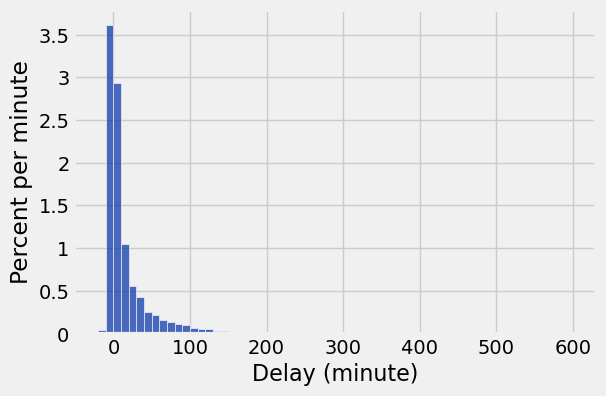

In [11]:
delay_bins = np.append(np.arange(-20, 301, 10), 600)
united.hist('Delay', bins = delay_bins, unit = 'minute')

In [12]:
united.where('Delay', are.above(200)).num_rows/united.num_rows

0.008390596745027125

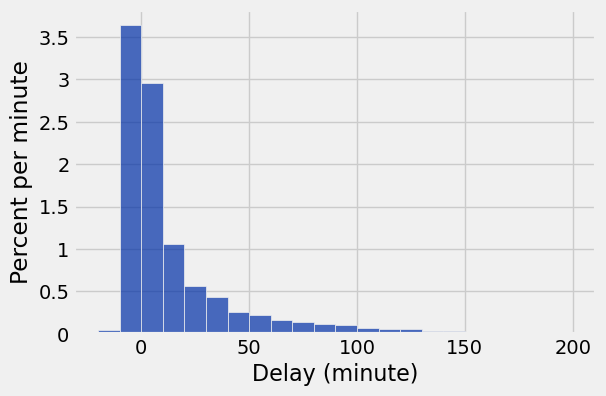

In [13]:
delay_bins = np.arange(-20, 201, 10)
united.hist('Delay', bins = delay_bins, unit = 'minute')

The height of the [0, 10) bar is just under 3% per minute, which means that just under 30% of the flights had delays between 0 and 10 minutes. That is confirmed by counting rows:

In [14]:
united.where('Delay', are.between(0, 10)).num_rows/united.num_rows

0.2935985533453888

---

## Empirical Distribution of the Sample
* If the sample size is large, then the empirical distribution of a uniform random sample resembles the distribution of the population, with high probability
* Let us now think of the 13,825 flights as a population, and draw random samples from it with replacement. 

* It is helpful to package our code into a function.

The function empirical_hist_delay takes the sample size as its argument and draws an empiricial histogram of the results.

In [15]:
def empirical_hist_delay(n):
    united.sample(n).hist('Delay', bins = delay_bins, unit = 'minute')

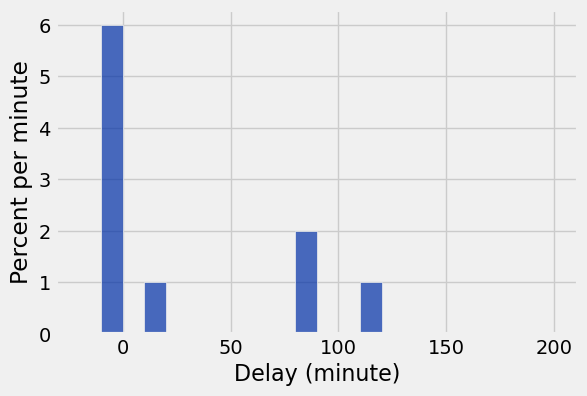

In [16]:
empirical_hist_delay(10)

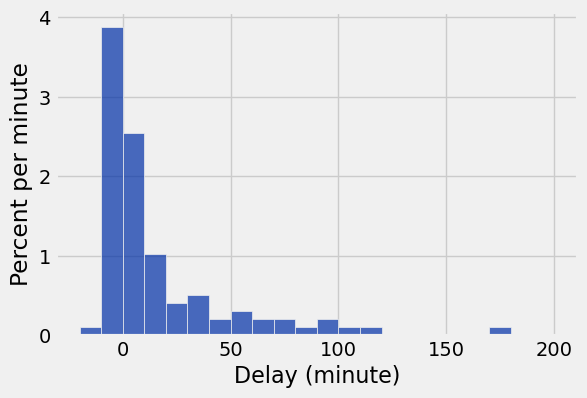

In [17]:
empirical_hist_delay(100)

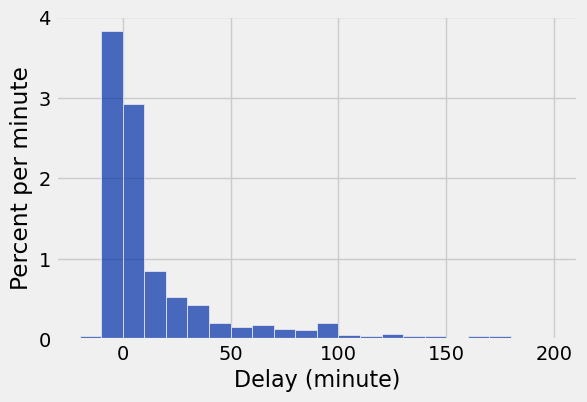

In [18]:
empirical_hist_delay(1000)

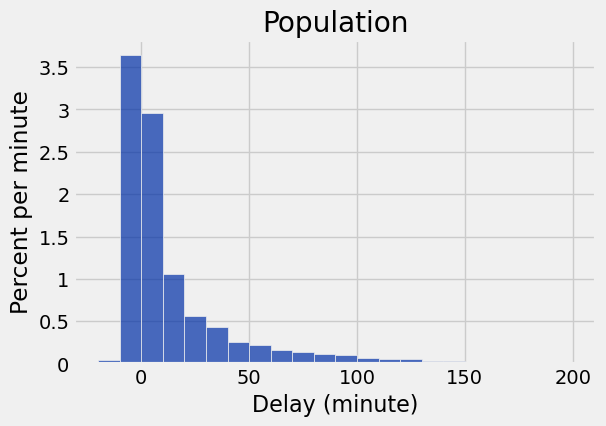

In [19]:
delay_bins = np.arange(-20, 201, 10)
united.hist('Delay', bins = delay_bins, unit = 'minute')
plt.title('Population');

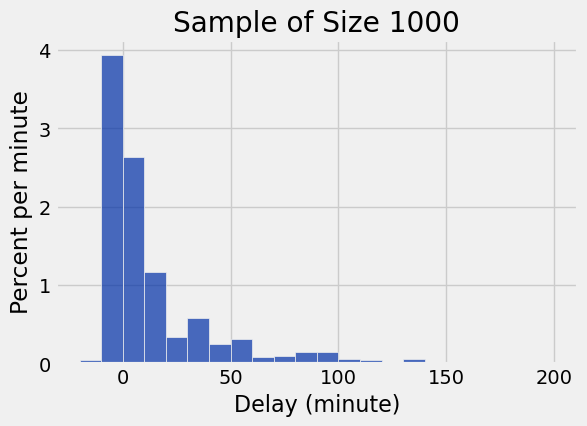

In [20]:
sample_1000 = united.sample(1000)
sample_1000.hist('Delay', bins = delay_bins, unit = 'minute')
plt.title('Sample of Size 1000');

---

## A Statistic

---

### Inference


1) `Statistical inferences` are conclusions which are made based on data in random samples

* Example: use the data to guess the number of an unknown (fixed) number
* Create an estimate, which depends on the random sample, of the unknown quantity

2)  `Parameter`: a number associated with the population
3) `Statistic`: a number calculated from the sample

    A statistic can be used as an estimate of a parameter == a number calculated from the sample can be used as an estimate of a number associated with the population



---

### Terminology

* Parameter: A number associated with the population
* Statistic: A number calculated from the sample
* A statistic can be used as an estimate of a parameter

---

## Probability vs. Empirical Distributions
#### `Probability distributions` are...
* varying, since random samples vary
* including all posisble values of the statistic and all the corresponding probabilities
* sometimes hard to calculate! You'll either have to do the math or generate all possible samples and calculate the statistic based on each sample

#### `Empirical distributions` are...
* based on simulated values of the statistic
* consist of all the observed values of the statistic and the proportion of times each value appeared
* is a good approximation to the probability distribution of the statistic (iff the number of repetitions in the simulation is fairly large)


### Simulating Statistics

Recall the median for the flight delays (parameter) and compare it to the median statistic associated with a random sample of 10 flights.

In [15]:
# (Population) Parameter
np.median(united.column('Delay'))

2.0

In [ ]:
united.where('Delay', are.below_or_equal_to(2)).num_rows / united.num_rows

In [ ]:
united.where('Delay', are.equal_to(2)).num_rows

In [ ]:
# (Sample) Statistic
np.median(united.sample(10).column('Delay'))

---

Define a function that randomly samples delay data for an inputted sample size and returns the median delay for that sample.

In [16]:
def sample_median(size):
    return np.median(united.sample(size).column('Delay'))

In [17]:
sample_median(10)

4.5

---

Simulate randomly sampling 10 flights 1000 times and storing the sample delay medians for each iteration. Add the results to a table and visualize the sampling distribution.

Repeat the sample simulation except use a sample size of 1000, instead of 10.

In [18]:
sample_medians = make_array()

for i in np.arange(1000):
    new_median = sample_median(10)
    sample_medians = np.append(sample_medians, new_median)

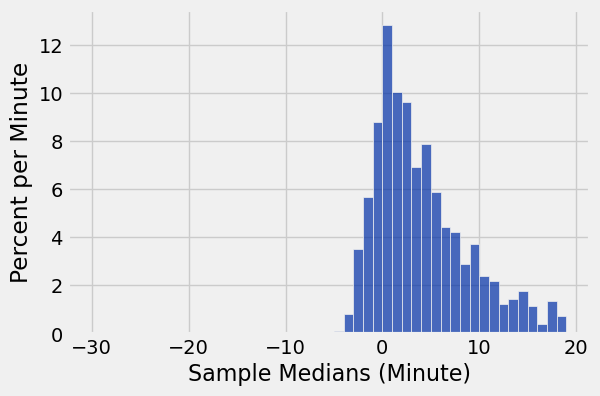

In [20]:
Table().with_column('Sample Medians', sample_medians).hist(bins = np.arange(-30,20), unit='Minute')

---

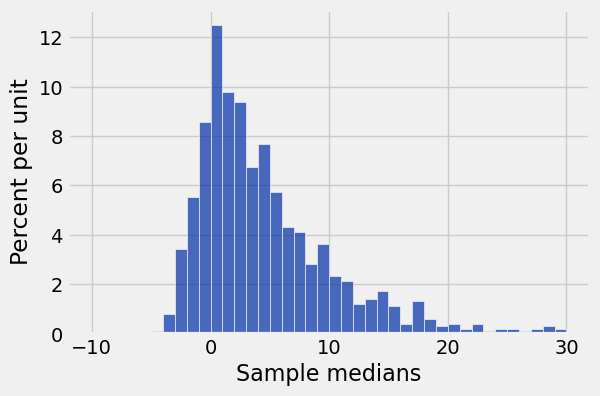

In [21]:
Table().with_column('Sample medians', sample_medians).hist(bins = np.arange(-10,31))

---

### Probability Distribution of a Statistic

* Values of a statistic vary because random samples vary
* Sampling distribution (or probability distribution) of the statistic:
    * All possible values of the statistic,
    * and all the corresponding probabilities
    * Can be hard to calculate
        * Either have to do the math
        * Or have to generate all possible samples and calculate the statistic based on each sample


---

### Empirical Distribution of a Statistic

* Empirical distribution of the statistic:
    * Based on simulated values of the statistic
    * Consists of all the observed values of the statistic,
    * and the proportion of times each value appeared
* Good approximation to the probability distribution of the statistic if the number of repetitions in the simulation is large


--- 

# Models

---

## Outline

* [Assessing Models](#Assessing-Models)
* [Jury-Selection](#Jury-Selection)
* [A Genetic Model](#A-Genetic-Model)
* [Two Viewpoints](#Two-Viewpoints)

---

## Assessing Models

---

### Models

* A model is a set of assumptions about the data
* In data science, many models involve assumptions about processes that involve randomness ("Chance models")
* Key question: Does the model fit the data?

---

### Approach to Assessment

* If we can simulate data according to the assumptions of the model, we can learn what the model predicts.
* We can then compare the predictions to the data that were observed.
* If the data and the model's predictions are not consistent, that is evidence against the model.

---

## Jury Selection

---

### Swain vs. Alabama, 1965

* Talladega County, Alabama
* Robert Swain, Black man convicted of crime
* Appeal: one factor was all-White jury
* Only men 21 years or older were allowed to serve
* 26% of this population were Black
* Swain's jury panel consisted of 100 men
* 8 men on the panel were Black

---

### Supreme Court Ruling (In English ... of the time)

* About disparities between the percentages in the eligible population and the jury panel, the Supreme Court wrote: 
> "... the overall percentage disparity has been small and reflects no studied attempt to include or exclude a specified number of Negroes"
* The Supreme Court denied Robert Swain’s appeal


---

### Supreme Court Ruling (in Data)

* Paraphrase: 8/100 is less than 26%, but not different enough to show Black men were systematically excluded
* Question: is 8/100 a realistic outcome if the jury panel selection process were truly unbiased?

---

### Sampling from a Distribution

* Sample at random from a categorical distribution using `sample_proportions(sample_size, pop_distribution)`
* Samples at random from the population returns an array containing the distribution of the categories in the sample


---

### Swain vs. Alabama

* Create a 2-valued array that reflects the proportion of the population that is Black and not Black.
* Use `sample_proportions` to create the proportions of a sample of size 100 from the population defined by the above array values.
* Define a function to return the proportion of Black individuals in a random sample of size 100 from the given population.
* Visualize the distribution by calling that function 10,000 times.
* Find the proportion of the simulated proportions that have a number of Black men on the panel that is at least as extreme as the observed number of 8 out of 100.

In [8]:
sample_size = 100
eligible_population = [0.26, 0.74]

In [9]:
sample_proportions(sample_size, eligible_population).item(0)

0.26

In [10]:
def one_simulated_count():
    return sample_size * sample_proportions(sample_size, eligible_population).item(0)

In [11]:
one_simulated_count()

30.0

In [14]:
counts = make_array()
repetitions = 10000
for i in np.arange(repetitions):
    counts = np.append(counts, one_simulated_count())
counts

array([ 29.,  22.,  29., ...,  30.,  30.,  24.])

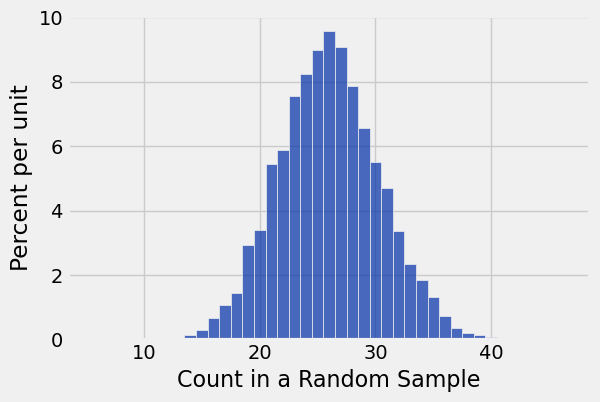

In [15]:
Table().with_column(
    'Count in a Random Sample', counts
).hist(bins = np.arange(5.5, 46.6, 1))

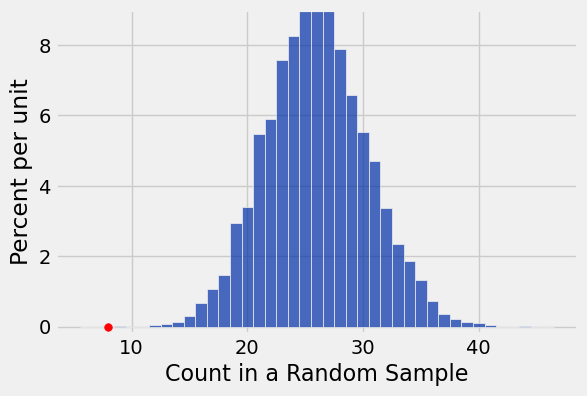

In [19]:
Table().with_column(
    'Count in a Random Sample', counts
).hist(bins = np.arange(5.5, 46.6, 1))
plt.ylim(-0.002, 0.09)
plt.scatter(8, 0, color='red', s=30);

---

## A Genetic Model

---

### Gregor Mendel, 1822-1884

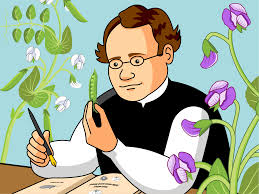

---

### A Model

* Pea plants of a particular kind
* Each one has either purple flowers or white flowers
* Mendel’s model: Each plant is purple-flowering with chance 75%, regardless of the colors of the other plants
* Question: Is the model good, or not?


---

### Choosing a Statistic

* Take a sample, see what percent are purple-flowering
* If that percent is much larger or much smaller than 75, that is evidence against the model
* Distance from 75 is the key
* Statistic: `abs(sample_percent_of_purple_flowering_plants - 75)`
* If the statistic is large, that is evidence against the model


---

### Mendel and Pea Flowers

Mendel had 929 plants, of which 709 had purple flowers:

* Define the observed proportion of purple flowers in Mendel's data and the predicted population proportions for purple and non-purple flowers.
* Simulate sampling 929 plants from a population with the proportions predicted by Mendel.
* Simulate randomly selecting samples of 929 plants based on Mendel's model.
* Repeat this process 10000 times and visualize the distribution of the sample proportions.
* Visualize the distribution of the test statistics created from the simulations and identify where the observed statistic fits in the distribution.
* Find the proportion of the distribution that have a value that is as extreme, or more extreme, than observed statistic.

In [ ]:
## Gregor Mendel had 929 plants, of which 709 had purple flowers
## Pea plants of a particular kind
## Each one has either purple flowers or white flowers
observed_purples = 709 / 929
observed_purples

In [ ]:
expected_prop = 0.75

In [ ]:
mendel_proportions = make_array(.75, .25)

flowers = sample_proportions(929, mendel_proportions)
flowers

In [ ]:
simulated_proportion_purple = flowers.item(0)
simulated_proportion_white = flowers.item(1)

print("In our simulation, " + str(simulated_proportion_purple) + " of flowers were purple and " \
      + str(simulated_proportion_white) + " of flowers were white.")

In [ ]:
perecnt_purple = sample_proportions(929, mendel_proportions).item(0) * 100
perecnt_purple

In [ ]:
def statistic_distance():
    return abs(perecnt_purple - 75)

In [ ]:
perecnt_purple = statistic_distance()
perecnt_purple 

In [ ]:
# This saves the random state of our code so that we can 
# generate the same numbers each time we run the code.
# Generates pseudo-random number based on seed. Seed can be any number.
np.random.seed(16)

mendel_proportions = make_array(.75, .25) 
simulated_proportion  = sample_proportions(929, mendel_proportions).item(0) 
one_distance =  abs(100 * simulated_proportion  - 75)
one_distance

In [ ]:
def one_simulated_distance(mendel_proportions, expected_proportion):
    '''Simulates 929
    Returns one statistic from the simulation.'''

    simulated_proportion = sample_proportions(292, mendel_proportions).item(0)
    one_distance =  abs(100 * simulated_proportion  - 75)
    return one_distance

In [ ]:
# Simulating Multiple Values of the Statistic
# The focus of our analysis is the variability in the counts.
# Let’s generate 10,000 simulated values.
num_repetitions = 10000

distances  = make_array() 

for i in np.arange(num_repetitions):
    one_distance = one_simulated_distance(mendel_proportions, expected_prop)
    distances = np.append(distances, one_distance)
distances

In [ ]:
Table().with_column("Distance From 75",distances).hist()

In [ ]:
observed_statistic = abs ( 100 * (705 / 929) - 75)
observed_statistic

In [ ]:
Table().with_column(
    'Distance between Sample % and 75%', distances
).hist()

plt.title('Prediction Made by the Null Hypothesis');

In [ ]:
Table().with_column(
    'Distance between Sample % and 75%', distances
).hist()
plt.ylim(-0.02, 0.5)
plt.title('Prediction Made by the Null Hypothesis')
plt.scatter(observed_statistic, 0, color='red', s=40);

---

## Two Viewpoints

---

### Model and Alternative

* Jury selection:
    * Model: The people on the jury panels were selected at random from the eligible population
    * Alternative viewpoint: No, they weren't
* Genetics:
    * Model: Each plant has a 75% chance of having purple flowers
    * Alternative viewpoint: No, it doesn't

---

# Comparing Distributions

---

## Outline

* [Comparing Distributions](#Comparing-Distributions)
* [A New Statistic](#A-New-Statistic)
* [Testing Hypotheses](#Testing-Hypotheses)

---

## Comparing Distributions

---

### Jury Selection in Alameda County

<img src="./ACLU_report.png" alt="ACLU Report" width=40%>

Report Source: [ACLU of Northern California - RACIAL AND ETHNIC DISPARITIES IN ALAMEDA COUNTY JURY POOLS (2010)](https://www.aclunc.org/sites/default/files/racial_and_ethnic_disparities_in_alameda_county_jury_pools.pdf)

---

### Jury Panels

<img src="./jury_selection_process.png" alt="jury selection process" width = 80%>

Section 197 of California's Code of Civil Procedure says, 
> "All persons selected for jury service shall be selected at random, from a source or sources inclusive of a representative cross section of the population of the area served by the court."

---

### Demo: Alameda County Jury Panels

* Visualize the the eligible and panel distributions of ethnicities based on the Totals in the report.
* Under the model, define an array that represents the distribution of people from which the jurors are randomly sampled
* Simulate a random draw of 1423 jurors from this distribution
* The actual observed distribution (Panels) looks quite different from the simulation -- try simulating this several times to confirm!
* Visualize the results of the last simulation.

In [ ]:
jury = Table().with_columns(
    'Ethnicity', make_array('Asian/PI', 'Black/AA', 'Caucasian', 'Hispanic', 'Other'),
    'Eligible', make_array(0.15, 0.18, 0.54, 0.12, 0.01),
    'Panels', make_array(0.26, 0.08, 0.54, 0.08, 0.04)
)

jury

In [ ]:
jury.barh('Ethnicity')

In [ ]:
eligible_population = jury.column('Eligible')
sample_distribution = sample_proportions(1453, eligible_population)
panels_and_sample = jury.with_column('Random Sample', sample_distribution)
panels_and_sample

In [ ]:
panels_and_sample.barh('Ethnicity')

In [ ]:
jury.barh('Ethnicity')

In [ ]:
# Augment the table with a column of differences between proportions

jury_with_diffs = jury.with_column(
    'Difference', jury.column('Panels') - jury.column('Eligible')
)
jury_with_diffs

In [ ]:
jury_with_diffs = jury_with_diffs.with_column(
    'Absolute Difference', np.abs(jury_with_diffs.column('Difference'))
)

jury_with_diffs

In [ ]:
jury_with_diffs.column('Absolute Difference').sum() / 2

---

## A New Statistic

---

### Distance Between Distributions

* People on the panels are of multiple ethnicities
* Distribution of ethnicities is categorical
* To see whether the distribution of ethnicities of the panels is close to that of the eligible jurors, we have to measure the distance between two categorical distributions


---

### Total Variation Distance

Total Variation Distance (TVD) Recipe:
* For each category, compute the difference in proportions between two distributions
* Take the absolute value of each difference
* Sum, and then divide the sum by 2


---

### Total Variation Distance

* Define a function that calculates the total_variation_distance for two provided distribution arrays.
* Calculate the TVD of our observed data (Panels) from their expected values assuming the model is true (Eligible)
* Calculate the TVD of a model simulation from its expected values
* Replicate creating sample juries and calculate the TVD in relation to the model 10000 times.
* Visualize how the observed statistic fits in the distribution formed from those simulated TVD values.
* Find the proportion of the simulated TVD's that are at least as extreme as the observed statistic.

In [ ]:
def total_variation_distance(distribution_1, distribution_2):
    return sum(np.abs(distribution_1 - distribution_2)) / 2

In [ ]:
dist1 = make_array(1, 2, 3)
dist2 = make_array(0, 2, 4)
total_variation_distance(dist1, dist2)

In [ ]:
total_variation_distance(jury.column('Panels'), jury.column('Eligible'))

In [ ]:
sample_distribution = sample_proportions(1453, eligible_population)
total_variation_distance(sample_distribution, eligible_population)

In [ ]:
# Simulate one simulated value of 
# the total variation distance between
# the distribution of a sample selected at random
# and the distribution of the eligible population

def one_simulated_tvd():
    sample_distribution = sample_proportions(1453, eligible_population)
    return total_variation_distance(sample_distribution, eligible_population)   

In [ ]:
tvds = make_array()
repetitions = 5000
for i in np.arange(repetitions):
    tvds = np.append(tvds, one_simulated_tvd())

In [ ]:
Table().with_column('TVD', tvds).hist(bins=np.arange(0, 0.2, 0.005))

# Plotting parameters; you can ignore this code
plt.title('Prediction Assuming Random Selection')
plt.xlim(0, 0.15)
plt.ylim(-5, 50)
plt.scatter(0.14, 0, color='red', s=30);

---

### Summary of the Method

To assess whether a sample was drawn randomly from a known categorical distribution:
* Use TVD as the statistic because it measures the distance between categorical distributions
* Sample at random from the population and compute the TVD from the random sample; repeat numerous times
* Compare:
    * Empirical distribution of simulated TVDs
    * Actual TVD from the sample in the study


---

## Testing Hypotheses

---

### Testing Hypotheses

* A test chooses between two views of how data were generated
* The views are called hypotheses
* The test picks the hypothesis that is better supported by the observed data


---

### Null and Alternative

The method only works if we can simulate data under one of the hypotheses.
* Null hypothesis:
    * A well defined chance model about how the data were generated
    * We can simulate data under the assumptions of this model – “under the null hypothesis”
* Alternative hypothesis: A different view about the origin of the data


---

### Test Statistic

* The statistic that we choose to simulate, to decide between the two hypotheses
* Questions before choosing the statistic:
    * What values of the statistic will make us lean towards the null hypothesis?
    * What values will make us lean towards the alternative? Preferably, the answer should be just "high". Try to avoid "both high and low".


---

### Prediction Under the Null Hypothesis

* Simulate the test statistic under the null hypothesis; draw the histogram of the simulated values
* This displays the **empirical distribution of the statistic under the null hypothesis**
* It is a prediction about the statistic, made by the null hypothesis 
    * It shows all the likely values of the statistic
    * Also how likely they are (**if the null hypothesis is true**)
* The probabilities are approximate, because we can't generate all the possible random samples


---

### Conclusion of the Test

* Resolve choice between null and alternative hypotheses
    * Compare the **observed test statistic** and its empirical distribution under the null hypothesis
    * If the observed value is **not consistent** with the distribution, then the test favors the alternative ("data is more consistent with the alternative")
* Whether a value is consistent with a distribution:
    * A visualization may be sufficient
    * If not, there are conventions about "consistency"

---

# Decisions and Uncertainty

---

## Outline

* [Decisions and Uncertainty](#Decisions-and-Uncertainty)
* [Review: Terminology](#Review:-Terminology)
* [A Low Midterm Average](#A-Low-Midterm-Average)
* [Statistical Significance](#Statistical-Significance)
* [How We’ve Tested Thus Far](#How-We’ve-Tested-Thus-Far)

---

## Decisions and Uncertainty

---

### Incomplete Information

* We are trying to choose between two views of the world, based on data in a sample.
* It is not always clear whether the data are consistent with one view or the other.
* Random samples can turn out quite extreme. It is unlikely, but possible.

---

## Review: Terminology

---

### Testing Hypotheses

* A test chooses between two views of how data were generated
* The views are called hypotheses
* The test picks the hypothesis that is better supported by the observed data


---

### Null and Alternative

The method only works if we can simulate data under one of the hypotheses.
* Null hypothesis:
    * A well defined chance model about how the data were generated
    * We can simulate data under the assumptions of this model – “under the null hypothesis”
* Alternative hypothesis: A different view about the origin of the data


---

### Test Statistic

* The statistic that we choose to simulate, to decide between the two hypotheses
* Questions before choosing the statistic:
    * What values of the statistic will make us lean towards the null hypothesis?
    * What values will make us lean towards the alternative? Preferably, the answer should be just "high". Try to avoid "both high and low".


---

### Prediction Under the Null Hypothesis

* Simulate the test statistic under the null hypothesis; draw the histogram of the simulated values
* This displays the **empirical distribution of the statistic under the null hypothesis**
* It is a prediction about the statistic, made by the null hypothesis 
    * It shows all the likely values of the statistic
    * Also how likely they are (**if the null hypothesis is true**)
* The probabilities are approximate, because we can't generate all the possible random samples


---

### Conclusion of the Test

* Resolve choice between null and alternative hypotheses
    * Compare the **observed test statistic** and its empirical distribution under the null hypothesis
    * If the observed value is **not consistent** with the distribution, then the test favors the alternative ("data is more consistent with the alternative")
* Whether a value is consistent with a distribution:
    * A visualization may be sufficient
    * If not, find and interpret the proportion of the empirical distribution that is at least as extreme as our observation. This is called the **p-value**.

---

### Definition of the P-value

* The P-value is the chance, 
    * under the null hypothesis, 
    * that the test statistic 
    * is equal to the value that was observed in the data
    * or is even further in the direction of the alternative.
* Also known as the observed significance level


---

## Statistical Significance

---

### Proportion in the Tail

<img src="./tail_areas.png" alt="comparison of distributions" width=80%>

---

### Conventions About Inconsistency

* "Inconsistent with the null": The test statistic is in the tail of the empirical distribution under the null hypothesis
* "In the tail," first convention:
    * The proportion in the tail is less than 5%
    * The result is "statistically significant"
* "In the tail," second convention:
    * The proportion in the tail is less than 1%
    * The result is "highly statistically significant"


---

### Hypothesis Testing Review

* One Category (*ex: percent of flowers that are purple*)
    * Test Statistic (1): `empirical_percentage`
    * Test Statistic (2): `abs(empirical_percentage - null_percentage)`
    * How to Simulate: sample_proportions(n, null_dist)
* Multiple Categories (*ex: ethnicity distribution of jury panel*)
    * Test Statistic: `tvd(empirical_dist, null_dist)`
    * How to Simulate: `sample_proportions(n, null_dist)`
* Numerical Data (*ex: scores in a lab section*)
    * Test Statistic: `empirical_mean`
    * How to Simulate: `population_data.sample(n, with_replacement=False)`

---

## Attribution

This content is licensed under the <a href="https://creativecommons.org/licenses/by-nc-sa/4.0/">Creative Commons Attribution-NonCommercial-ShareAlike 4.0 International License (CC BY-NC-SA 4.0)</a> and derived from the <a href="https://www.data8.org/">Data 8: The Foundations of Data Science</a> offered by the University of California, Berkeley.

<img src="./by-nc-sa.png" width=100px>